In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

In [2]:
risk = pd.read_csv("../data/processed/risk_engineered.csv")
risk.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_MAX_DELAY,PAY_COUNT_DELAY_1plus,PAY_COUNT_DELAY_2plus,PAY_TREND,PAY_RATIO_LATEST,PAY_RATIO_MEAN,PROP_MONTHS_LOW_PAYMENT,PROP_MONTHS_ZERO_PAYMENT,PROP_MONTHS_OVERPAYMENT,PAY_DISCIPLINE_SCORE
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,2,2,2,4,0.000000,0.074038,1.000000,0.666667,0.000000,-2.000000
1,2,120000.0,2,2,2,26,-1,2,0,0,...,2,2,2,-3,0.000000,0.311916,0.666667,0.333333,0.000000,-1.166667
2,3,90000.0,2,2,2,34,0,0,0,0,...,0,0,0,0,0.051917,0.115141,1.000000,0.000000,0.000000,-1.000000
3,4,50000.0,2,2,1,37,0,0,0,0,...,0,0,0,0,0.042562,0.036396,1.000000,0.000000,0.000000,-1.000000
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,0,0,0,-1,0.232099,1.246958,0.833333,0.000000,0.166667,-0.666667


## Logistic Regression

In [3]:
# Target
y = risk["default.payment.next.month"]

# Features (excluding ID and target)
X = risk.drop(columns = ["ID", "default.payment.next.month"])

### Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE)

In [5]:
print("Train default rate", y_train.mean())
print("Test default rate", y_test.mean())

Train default rate 0.22120833333333334
Test default rate 0.22116666666666668


In [6]:
X_train.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_MAX_DELAY,PAY_COUNT_DELAY_1plus,PAY_COUNT_DELAY_2plus,PAY_TREND,PAY_RATIO_LATEST,PAY_RATIO_MEAN,PROP_MONTHS_LOW_PAYMENT,PROP_MONTHS_ZERO_PAYMENT,PROP_MONTHS_OVERPAYMENT,PAY_DISCIPLINE_SCORE
22788,160000.0,2,2,2,33,2,2,3,2,0,...,3,4,4,2,0.092724,0.040480,1.0,0.333333,0.0,-1.5
29006,150000.0,2,1,2,34,1,-1,-1,-2,-2,...,1,1,0,3,0.000000,0.000000,1.0,1.000000,0.0,-2.5
16950,10000.0,1,2,1,50,1,2,0,0,0,...,2,2,1,1,0.000197,0.080701,1.0,0.000000,0.0,-1.0
22280,220000.0,2,1,2,29,0,0,0,0,0,...,0,0,0,0,0.043987,0.037856,1.0,0.000000,0.0,-1.0
11346,310000.0,2,1,2,32,1,-2,-1,0,0,...,1,1,0,3,0.000000,0.000000,1.0,1.000000,0.0,-2.5


### Logistic Regression

In [7]:
original_cols = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

In [8]:
X_train_base = X_train[original_cols]
X_test_base = X_test[original_cols]

### Scaling (Logistic)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled = scaler.transform(X_test_base)

### Train the model

In [10]:
log_model = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Predictions & AUC

In [11]:
y_train_pred = log_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred = log_model.predict_proba(X_test_scaled)[:, 1]

auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print("Baseline Logistic AUC (Train):", round(auc_train, 4))
print("Baseline Logistic AUC (Test):", round(auc_test, 4))

Baseline Logistic AUC (Train): 0.7282
Baseline Logistic AUC (Test): 0.7076


### GINI

In [12]:
gini_train = 2 * auc_train - 1
gini_test = 2 * auc_test - 1

print("Baseline Logistic Gini (Train):", round(gini_train, 4))
print("Baseline Logistic Gini (Test):", round(gini_test, 4))

Baseline Logistic Gini (Train): 0.4563
Baseline Logistic Gini (Test): 0.4153


### KS

In [13]:
def calculate_ks(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    ks = max(tpr - fpr)
    return ks

In [14]:
ks_train = calculate_ks(y_train, y_train_pred)
ks_test = calculate_ks(y_test, y_test_pred)

print("Baseline Logistic KS (Train):", round(ks_train, 4))
print("Baseline Logistic KS (Test):", round(ks_test, 4))

Baseline Logistic KS (Train): 0.3813
Baseline Logistic KS (Test): 0.3634


## Logistic Regression + Engineered Features

In [15]:
y = risk["default.payment.next.month"]

# Features (excluding ID and target)
X_full = risk.drop(columns = ["ID", "default.payment.next.month"])

### Check NaN

In [16]:
X_full.isna().sum().sort_values(ascending=False).head(20)

PROP_MONTHS_ZERO_PAYMENT    966
PROP_MONTHS_OVERPAYMENT     966
PAY_DISCIPLINE_SCORE        966
PROP_MONTHS_LOW_PAYMENT     966
PAY_RATIO_MEAN              966
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
PAY_0                         0
AGE                           0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
PAY_AMT2                      0
dtype: int64

In [17]:
np.isinf(X_full).sum()

LIMIT_BAL                   0
SEX                         0
EDUCATION                   0
MARRIAGE                    0
AGE                         0
PAY_0                       0
PAY_2                       0
PAY_3                       0
PAY_4                       0
PAY_5                       0
PAY_6                       0
BILL_AMT1                   0
BILL_AMT2                   0
BILL_AMT3                   0
BILL_AMT4                   0
BILL_AMT5                   0
BILL_AMT6                   0
PAY_AMT1                    0
PAY_AMT2                    0
PAY_AMT3                    0
PAY_AMT4                    0
PAY_AMT5                    0
PAY_AMT6                    0
PAY_LATEST                  0
PAY_MEAN                    0
PAY_MAX_DELAY               0
PAY_COUNT_DELAY_1plus       0
PAY_COUNT_DELAY_2plus       0
PAY_TREND                   0
PAY_RATIO_LATEST            0
PAY_RATIO_MEAN              0
PROP_MONTHS_LOW_PAYMENT     0
PROP_MONTHS_ZERO_PAYMENT    0
PROP_MONTH

In [18]:
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(0)

In [19]:
X_full.isna().sum().sort_values(ascending=False).head(20)

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
dtype: int64

### Train/Test Split

In [20]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE
)

### Scaling

In [21]:
scaler_full = StandardScaler()

X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

### Train the model

In [22]:
log_model_full = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)
log_model_full.fit(X_train_full_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Predictions and metrics

In [23]:
y_train_pred_full = log_model_full.predict_proba(X_train_full_scaled)[:, 1]
y_test_pred_full = log_model_full.predict_proba(X_test_full_scaled)[:, 1]

auc_train_full = roc_auc_score(y_train, y_train_pred_full)
auc_test_full = roc_auc_score(y_test, y_test_pred_full)

print("Engineered Logistic AUC (Train):", round(auc_train_full, 4))
print("Engineered Logistic AUC (Test):", round(auc_test_full, 4))

Engineered Logistic AUC (Train): 0.77
Engineered Logistic AUC (Test): 0.7571


### GINI

In [24]:
gini_train_full = 2 * auc_train_full - 1
gini_test_full = 2 * auc_test_full - 1

print("Engineered Logistic Gini (Train):", round(gini_train_full, 4))
print("Engineered Logistic Gini (Test):", round(gini_test_full, 4))

Engineered Logistic Gini (Train): 0.5401
Engineered Logistic Gini (Test): 0.5142


### KS

In [25]:
ks_train_full = calculate_ks(y_train, y_train_pred_full)
ks_test_full = calculate_ks(y_test, y_test_pred_full)

print("Engineered Logistic KS (Train):", round(ks_train_full, 4))
print("Engineered Logistic KS (Test):", round(ks_test_full, 4))

Engineered Logistic KS (Train): 0.4197
Engineered Logistic KS (Test): 0.412


## What variables are actually explaining the risk?

### Extract coefficients

In [26]:
coefficients = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Coefficient": log_model_full.coef_[0]
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values("Abs_Coefficient", ascending=False)

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
27,PAY_COUNT_DELAY_2plus,1.260519,1.260519
26,PAY_COUNT_DELAY_1plus,-0.459878,0.459878
25,PAY_MAX_DELAY,0.353776,0.353776
0,LIMIT_BAL,-0.283988,0.283988
12,BILL_AMT2,0.191585,0.191585
31,PROP_MONTHS_LOW_PAYMENT,-0.169032,0.169032
7,PAY_3,-0.163030,0.163030
17,PAY_AMT1,-0.158796,0.158796
18,PAY_AMT2,-0.133058,0.133058
11,BILL_AMT1,-0.127724,0.127724


In [27]:
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
coefficients.sort_values("Abs_Coefficient", ascending=False).head(10)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
27,PAY_COUNT_DELAY_2plus,1.260519,1.260519,3.527252
26,PAY_COUNT_DELAY_1plus,-0.459878,0.459878,0.631361
25,PAY_MAX_DELAY,0.353776,0.353776,1.424437
0,LIMIT_BAL,-0.283988,0.283988,0.752775
12,BILL_AMT2,0.191585,0.191585,1.211168
31,PROP_MONTHS_LOW_PAYMENT,-0.169032,0.169032,0.844481
7,PAY_3,-0.163030,0.163030,0.849566
17,PAY_AMT1,-0.158796,0.158796,0.853170
18,PAY_AMT2,-0.133058,0.133058,0.875414
11,BILL_AMT1,-0.127724,0.127724,0.880096


### VIF

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_full.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_full.values, i)
    for i in range(X_train_full.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.head(15)

d:\IT\mis_entornos\general\general_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
8,PAY_4,inf
5,PAY_0,inf
6,PAY_2,inf
34,PAY_DISCIPLINE_SCORE,inf
28,PAY_TREND,inf
32,PROP_MONTHS_ZERO_PAYMENT,inf
7,PAY_3,inf
9,PAY_5,inf
10,PAY_6,inf
23,PAY_LATEST,inf


## Classical modeling strategy

### Clean props

In [29]:
cols_to_drop = [
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'PAY_MEAN','PAY_LATEST','PAY_TREND','PAY_DISCIPLINE_SCORE'
]

X_train_reduced = X_train_full.drop(columns = cols_to_drop)
X_test_reduced = X_test_full.drop(columns = cols_to_drop)

### Recalculate VIF

In [30]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_reduced.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_reduced.values, i)
    for i in range(X_train_reduced.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.head(15)

,Feature,VIF
6,BILL_AMT2,40.236985
7,BILL_AMT3,36.324512
9,BILL_AMT5,34.712309
18,PAY_COUNT_DELAY_1plus,34.458036
8,BILL_AMT4,30.040375
19,PAY_COUNT_DELAY_2plus,29.276760
10,BILL_AMT6,21.169773
5,BILL_AMT1,20.566170
22,PROP_MONTHS_LOW_PAYMENT,13.922522
4,AGE,12.824526


### Finer cleaning

In [31]:
X_train_reduced["BILL_MEAN"] = X_train_reduced[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]].mean(axis=1)

X_test_reduced["BILL_MEAN"] = X_test_reduced[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]].mean(axis=1)

In [32]:
new_cols_to_drop = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_COUNT_DELAY_1plus"]

In [33]:
X_train_new_reduced = X_train_reduced.drop(columns = new_cols_to_drop)
X_test_new_reduced = X_test_reduced.drop(columns = new_cols_to_drop)

In [34]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_new_reduced.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_new_reduced.values, i)
    for i in range(X_train_new_reduced.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.head(15)

,Feature,VIF
15,PROP_MONTHS_LOW_PAYMENT,13.302859
4,AGE,12.641880
1,SEX,9.736558
3,MARRIAGE,7.672643
2,EDUCATION,6.889070
0,LIMIT_BAL,4.106791
18,BILL_MEAN,2.858437
12,PAY_COUNT_DELAY_2plus,2.726430
11,PAY_MAX_DELAY,2.585929
17,PROP_MONTHS_OVERPAYMENT,2.573464


### Final cleaning

In [35]:
final_cols_to_drop = ["PROP_MONTHS_LOW_PAYMENT"]

X_train_final_reduced = X_train_new_reduced.drop(columns = final_cols_to_drop)
X_test_final_reduced = X_test_new_reduced.drop(columns = final_cols_to_drop)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_final_reduced.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_final_reduced.values, i)
    for i in range(X_train_final_reduced.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.head(15)

,Feature,VIF
4,AGE,11.255698
1,SEX,9.185293
2,EDUCATION,6.669363
3,MARRIAGE,6.402494
0,LIMIT_BAL,4.031042
12,PAY_COUNT_DELAY_2plus,2.726327
11,PAY_MAX_DELAY,2.557481
17,BILL_MEAN,2.514341
16,PROP_MONTHS_OVERPAYMENT,2.019633
15,PROP_MONTHS_ZERO_PAYMENT,1.757246


### Dataset control

In [36]:
print(X_train_final_reduced.shape)
print(X_test_final_reduced.shape)
print(set(X_train_final_reduced.columns) - set(X_test_final_reduced.columns))

(24000, 18)
(6000, 18)
set()


### Scaling & Train the model

In [37]:
from sklearn.pipeline import Pipeline

log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

log_pipeline.fit(X_train_final_reduced, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

### Predictions and metrics

In [38]:
y_train_probs = log_pipeline.predict_proba(X_train_final_reduced)[:, 1]
y_test_probs  = log_pipeline.predict_proba(X_test_final_reduced)[:, 1]

auc_train_final = roc_auc_score(y_train, y_train_probs)
auc_test_final = roc_auc_score(y_test, y_test_probs)

print("Final Logistic AUC (Train):", round(auc_train_final, 4))
print("Final Logistic AUC (Test):", round(auc_test_final, 4))

Final Logistic AUC (Train): 0.7506
Final Logistic AUC (Test): 0.7311


### GINI

In [39]:
gini_train_final = 2 * auc_train_final - 1
gini_test_final = 2 * auc_test_final - 1

print("Final Logistic Gini (Train):", round(gini_train_final, 4))
print("Final Logistic Gini (Test):", round(gini_test_final, 4))

Final Logistic Gini (Train): 0.5011
Final Logistic Gini (Test): 0.4622


### KS

In [40]:
ks_train_final = calculate_ks(y_train, y_train_probs)
ks_test_final = calculate_ks(y_test, y_test_probs)

print("Final Logistic KS (Train):", round(ks_train_final, 4))
print("Final Logistic KS (Test):", round(ks_test_final, 4))

Final Logistic KS (Train): 0.4044
Final Logistic KS (Test): 0.3819


## Random Forest Comparison

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    min_samples_split = 50,
    min_samples_leaf = 25,
    random_state = RANDOM_STATE,
    n_jobs = -1
)

rf_model.fit(X_train_final_reduced, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [43]:
y_train_probs_rf = rf_model.predict_proba(X_train_final_reduced)[:, 1]
y_test_probs_rf = rf_model.predict_proba(X_test_final_reduced)[:, 1]

### Metrics

In [44]:
auc_train_rf = roc_auc_score(y_train, y_train_probs_rf)
auc_test_rf  = roc_auc_score(y_test, y_test_probs_rf)

gini_train_rf = 2 * auc_train_rf - 1
gini_test_rf  = 2 * auc_test_rf - 1

ks_train_rf = calculate_ks(y_train, y_train_probs_rf)
ks_test_rf  = calculate_ks(y_test, y_test_probs_rf)

print("RF AUC (Train):", round(auc_train_rf, 4))
print("RF AUC (Test):", round(auc_test_rf, 4))
print("RF Gini (Test):", round(gini_test_rf, 4))
print("RF KS (Test):", round(ks_test_rf, 4))

RF AUC (Train): 0.8675
RF AUC (Test): 0.7691
RF Gini (Test): 0.5381
RF KS (Test): 0.4143


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X_train_final_reduced.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
12,PAY_COUNT_DELAY_2plus,0.268849
11,PAY_MAX_DELAY,0.211637
17,BILL_MEAN,0.055601
14,PAY_RATIO_MEAN,0.054746
0,LIMIT_BAL,0.052390
5,PAY_AMT1,0.050957
15,PROP_MONTHS_ZERO_PAYMENT,0.042638
13,PAY_RATIO_LATEST,0.041285
6,PAY_AMT2,0.040740
7,PAY_AMT3,0.034148


### Random Forest Hyperparameter Optimization

#### Grid

In [48]:
param_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [10, 20, 40, 60],
    "min_samples_split": [20, 50, 100],
    "max_features": ["sqrt", 0.5, 0.8]
}

In [49]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    n_estimators = 400,
    random_state = RANDOM_STATE,
    n_jobs = 1
)

random_search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_grid,
    n_iter = 15,
    scoring = "roc_auc",
    cv = 3,
    verbose = 1,
    random_state = RANDOM_STATE,
    n_jobs = -1
)

random_search.fit(X_train_final_reduced, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


d:\IT\mis_entornos\general\general_env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 0.5, ...], 'min_samples_leaf': [10, 20, ...], 'min_samples_split': [20, 50, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

#### Model

In [50]:
best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'min_samples_split': 50, 'min_samples_leaf': 60, 'max_features': 0.8, 'max_depth': 10}


#### Metrics

In [51]:
y_train_probs_rf = best_rf.predict_proba(X_train_final_reduced)[:,1]
y_test_probs_rf  = best_rf.predict_proba(X_test_final_reduced)[:,1]

auc_train_rf = roc_auc_score(y_train, y_train_probs_rf)
auc_test_rf  = roc_auc_score(y_test, y_test_probs_rf)

gini_train_rf = 2 * auc_train_rf - 1
gini_test_rf  = 2 * auc_test_rf - 1

ks_train_rf = calculate_ks(y_train, y_train_probs_rf)
ks_test_rf  = calculate_ks(y_test, y_test_probs_rf)

print("Tuned RF AUC (Test):", round(auc_test_rf,4))
print("Tuned RF KS (Test):", round(ks_test_rf,4))

Tuned RF AUC (Test): 0.7696
Tuned RF KS (Test): 0.4184


In [52]:
y_train_probs_rf_tuned = best_rf.predict_proba(X_train_final_reduced)[:, 1]
y_test_probs_rf_tuned  = best_rf.predict_proba(X_test_final_reduced)[:, 1]

auc_train_rf_tuned = roc_auc_score(y_train, y_train_probs_rf_tuned)
auc_test_rf_tuned  = roc_auc_score(y_test, y_test_probs_rf_tuned)

gini_train_rf_tuned = 2 * auc_train_rf_tuned - 1
gini_test_rf_tuned  = 2 * auc_test_rf_tuned - 1

ks_train_rf_tuned = calculate_ks(y_train, y_train_probs_rf_tuned)
ks_test_rf_tuned  = calculate_ks(y_test, y_test_probs_rf_tuned)

print("Tuned RF AUC (Train):", round(auc_train_rf_tuned, 4))
print("Tuned RF AUC (Test):", round(auc_test_rf_tuned, 4))
print("Tuned RF KS (Train):", round(ks_train_rf_tuned, 4))
print("Tuned RF KS (Test):", round(ks_test_rf_tuned, 4))

Tuned RF AUC (Train): 0.8252
Tuned RF AUC (Test): 0.7696
Tuned RF KS (Train): 0.493
Tuned RF KS (Test): 0.4184


#### ROC Comparison

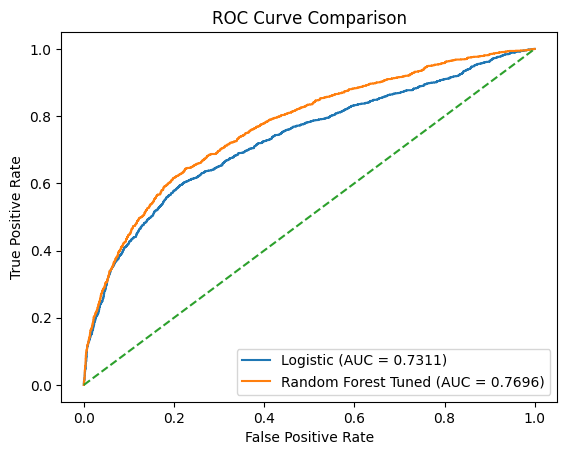

In [53]:
from sklearn.metrics import auc

# Probabilidades logística (asegurate de tenerlas calculadas)
y_test_probs_log = log_pipeline.predict_proba(X_test_final_reduced)[:, 1]

# Probabilidades RF tuned (ya las tenés)
y_test_probs_rf = y_test_probs_rf_tuned

# Curvas ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_test_probs_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_probs_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest Tuned (AUC = {auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Lift Table by deciles

In [54]:
def create_lift_table(y_true, y_probs, n_bins=10):
    
    df = pd.DataFrame({
        "target": y_true,
        "score": y_probs
    })
    
    # Ordenamos por score descendente (mayor riesgo primero)
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    
    # Creamos deciles
    df["decile"] = pd.qcut(df.index, q=n_bins, labels=False)
    
    # Agregaciones
    lift_table = df.groupby("decile").agg(
        total=("target", "count"),
        defaults=("target", "sum")
    ).reset_index()
    
    lift_table["default_rate"] = lift_table["defaults"] / lift_table["total"]
    lift_table["cum_defaults"] = lift_table["defaults"].cumsum()
    lift_table["cum_default_rate"] = lift_table["cum_defaults"] / lift_table["defaults"].sum()
    
    return lift_table

In [55]:
lift_log = create_lift_table(y_test, y_test_probs_log)
lift_rf  = create_lift_table(y_test, y_test_probs_rf_tuned)

print("Logistic Lift Table")
display(lift_log)

print("Random Forest Lift Table")
display(lift_rf)

Logistic Lift Table


,decile,total,defaults,default_rate,cum_defaults,cum_default_rate
0,0,600,376,0.626667,376,0.283346
1,1,600,241,0.401667,617,0.464959
2,2,600,173,0.288333,790,0.595328
3,3,600,103,0.171667,893,0.672946
4,4,600,95,0.158333,988,0.744537
5,5,600,69,0.115000,1057,0.796534
6,6,600,76,0.126667,1133,0.853806
7,7,600,61,0.101667,1194,0.899774
8,8,600,77,0.128333,1271,0.957800
9,9,600,56,0.093333,1327,1.000000


Random Forest Lift Table


,decile,total,defaults,default_rate,cum_defaults,cum_default_rate
0,0,600,386,0.643333,386,0.290882
1,1,600,261,0.435000,647,0.487566
2,2,600,179,0.298333,826,0.622457
3,3,600,115,0.191667,941,0.709118
4,4,600,109,0.181667,1050,0.791258
5,5,600,83,0.138333,1133,0.853806
6,6,600,58,0.096667,1191,0.897513
7,7,600,64,0.106667,1255,0.945742
8,8,600,43,0.071667,1298,0.978146
9,9,600,29,0.048333,1327,1.000000
